Przygotowanie danych

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

1.1. Wczytanie danych, sprawdzenie typów danych i kompletności danych, podstawowe statystyki.

In [2]:
data = pd.read_csv('Telco-Customer-Churn.csv')

data_types = data.dtypes

missing_values = data.isnull().sum()

basic_statistics = data.describe(include='all')

In [3]:
data_types

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [4]:
missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
basic_statistics

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032,7032.000000,7032,7032,7032.000000,7032,7032,7032,7032,...,7032,7032,7032,7032,7032,7032,7032,7032.000000,7032.000000,7032
unique,7032,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3549,NaN,3639,4933,NaN,6352,3385,3096,3497,...,3094,3472,2809,2781,3875,4168,2365,NaN,NaN,5163
mean,NaN,NaN,0.162400,NaN,NaN,32.421786,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2283.300441,NaN
std,NaN,NaN,0.368844,NaN,NaN,24.545260,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.862500,3794.737500,NaN


1.2. Utworzenie wykresu słupkowego:

1.2.1. ilości wystąpień kategorii dotyczącej atrybutu decyzyjnego,

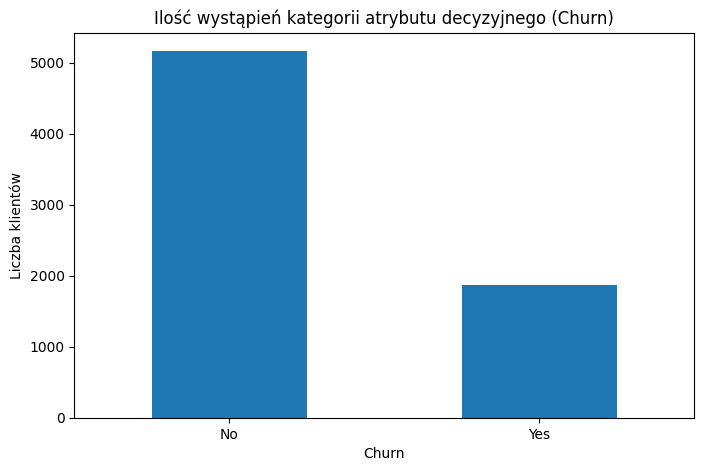

In [6]:
churn_counts = data['Churn'].value_counts()
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar')
plt.title("Ilość wystąpień kategorii atrybutu decyzyjnego (Churn)")
plt.xlabel("Churn")
plt.ylabel("Liczba klientów")
plt.xticks(rotation=0)
plt.show()

1.2.2. atrybut decyzyjny według płci.

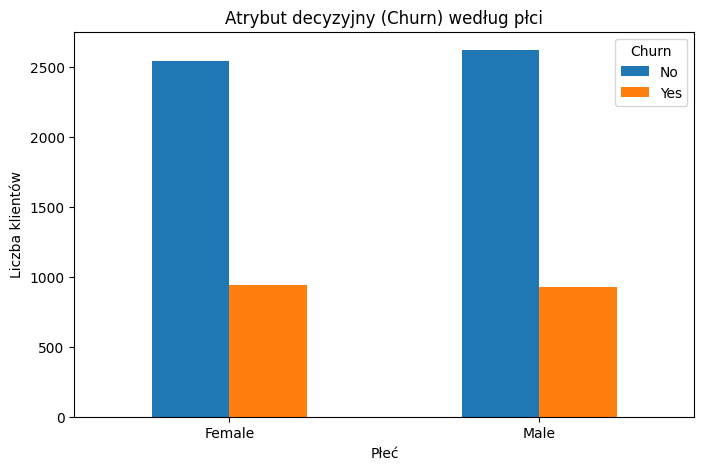

In [7]:
churn_by_gender = data.groupby(['gender', 'Churn']).size().unstack()
churn_by_gender.plot(kind='bar', figsize=(8, 5))
plt.title("Atrybut decyzyjny (Churn) według płci")
plt.xlabel("Płeć")
plt.ylabel("Liczba klientów")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

1.3. Wykres pudełkowy:

1.3.1. opłat całkowitych w zależności od klientów, którzy odeszli w ciągu ostatniego miesiąca.

<Figure size 800x500 with 0 Axes>

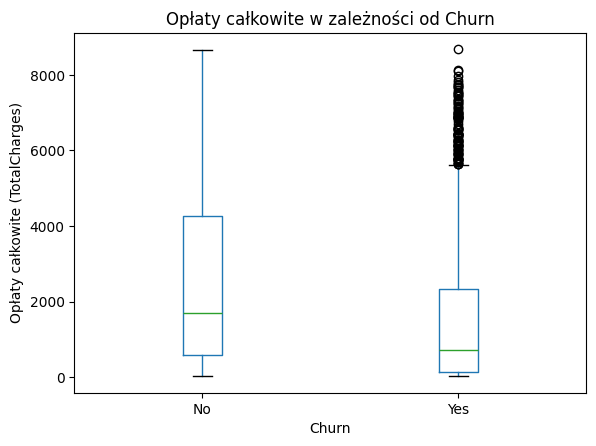

In [8]:
plt.figure(figsize=(8, 5))
data.boxplot(column='TotalCharges', by='Churn', grid=False)
plt.title("Opłaty całkowite w zależności od Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Opłaty całkowite (TotalCharges)")
plt.show()

1.3.2. ‘churn’ klientów w zależności długości czasu korzystania z usług.

<Figure size 800x500 with 0 Axes>

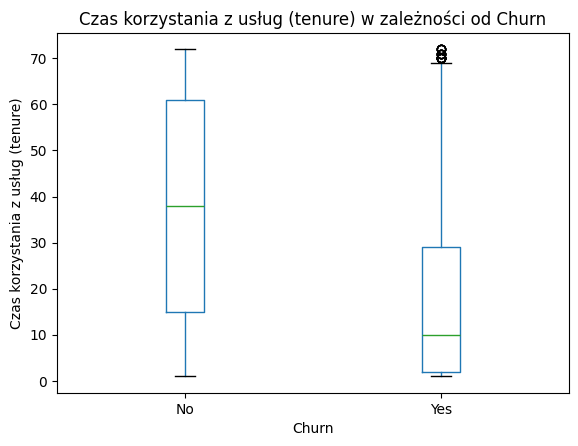

In [9]:
plt.figure(figsize=(8, 5))
data.boxplot(column='tenure', by='Churn', grid=False)
plt.title("Czas korzystania z usług (tenure) w zależności od Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Czas korzystania z usług (tenure)")
plt.show()

1.4. Wykres pudełkowy opłat całkowitych w zależności od rodzaju umowy z uwzględnieniem, klientów,
którzy odeszli w ciągu ostatniego miesiąca 'Churn'.

<Figure size 1000x600 with 0 Axes>

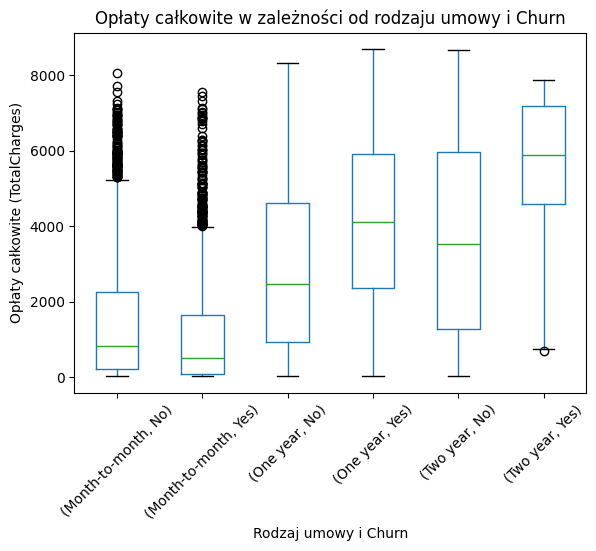

In [10]:
plt.figure(figsize=(10, 6))
data.boxplot(column='TotalCharges', by=['Contract', 'Churn'], grid=False)
plt.title("Opłaty całkowite w zależności od rodzaju umowy i Churn")
plt.suptitle("")
plt.xlabel("Rodzaj umowy i Churn")
plt.ylabel("Opłaty całkowite (TotalCharges)")
plt.xticks(rotation=45)
plt.show()

1.5. Utworzenie wykresu słupkowego wielkości korelacji z wyłączeniem cech ('customerID', 'tenure',
'MonthlyCharges', 'TotalCharges') z ‘Churn’ yes. Niektóre kolumny kategorialne należy
przekonwertować na zmienne fikcyjne.

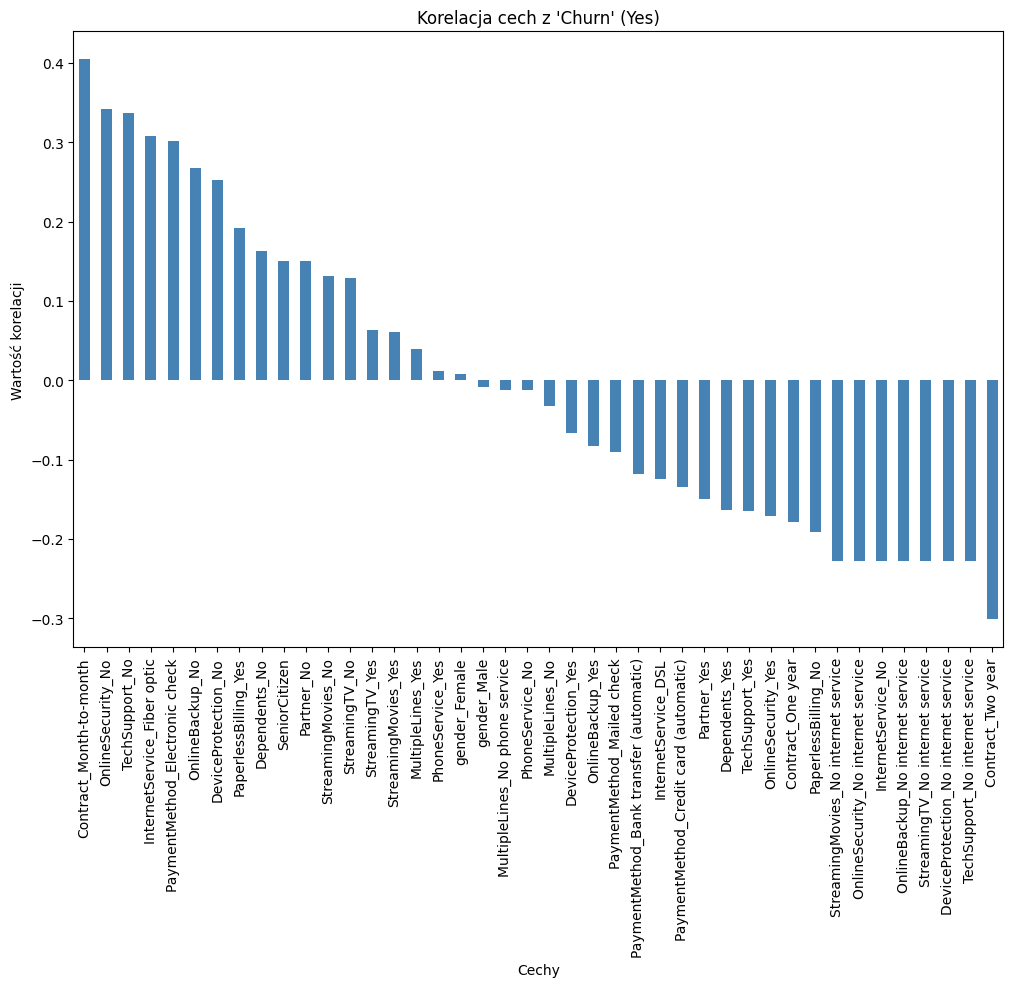

In [11]:
selected_columns = data.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'], axis=1)
df_encoded_reduced = pd.get_dummies(selected_columns, drop_first=False)
df_encoded_reduced = df_encoded_reduced.drop(columns=['Churn_No'])

correlations_reduced = df_encoded_reduced.corr()['Churn_Yes'].drop('Churn_Yes')

plt.figure(figsize=(12, 8))
correlations_reduced.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title("Korelacja cech z 'Churn' (Yes)")
plt.xlabel("Cechy")
plt.ylabel("Wartość korelacji")
plt.show()

1.6. Jakie są rodzaje zawieranych umów?

In [12]:
contract_types = data['Contract'].unique()
contract_types

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

1.7. Rozkład różnych usług używanych przez klientów.

In [13]:
service_columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

service_distributions = {col: data[col].value_counts() for col in service_columns}

for service, distribution in service_distributions.items():
    print(f"\nRozkład dla {service}:")
    print(distribution)


Rozkład dla PhoneService:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

Rozkład dla MultipleLines:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

Rozkład dla InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Rozkład dla OnlineSecurity:
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

Rozkład dla OnlineBackup:
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

Rozkład dla DeviceProtection:
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

Rozkład dla TechSupport:
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

Rozkład dla StreamingTV:

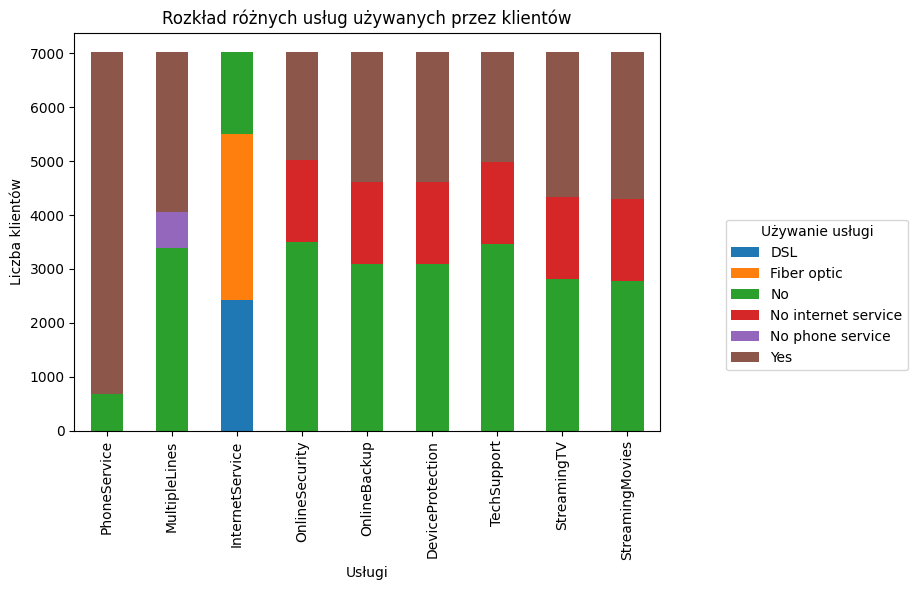

In [41]:
service_usage = data[service_columns].apply(pd.Series.value_counts).T

fig, ax = plt.subplots(figsize=(8, 6))
service_usage.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Rozkład różnych usług używanych przez klientów')
ax.set_xlabel('Usługi')
ax.set_ylabel('Liczba klientów')

ax.legend().remove()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), title='Używanie usługi')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()

1.8. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure').

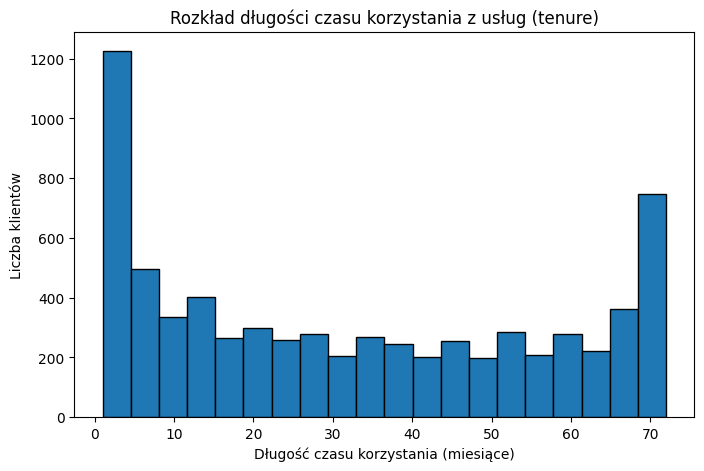

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(data['tenure'], bins=20, edgecolor='black')
plt.title("Rozkład długości czasu korzystania z usług (tenure)")
plt.xlabel("Długość czasu korzystania (miesiące)")
plt.ylabel("Liczba klientów")
plt.show()

1.9. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure'), z różnicowaniem według klientów, którzy odeszli w ciągu ostatniego miesiąca oraz typu
umowy.

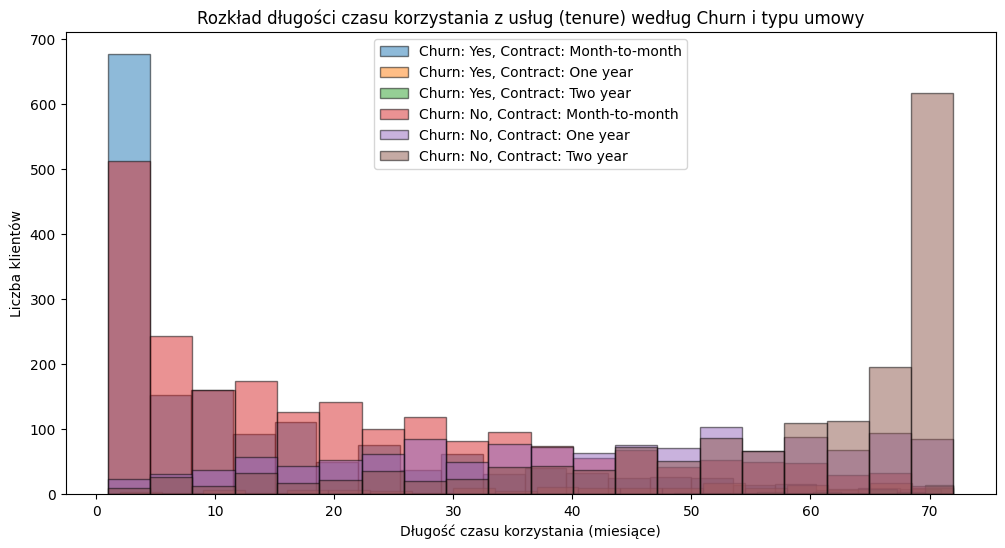

In [15]:
plt.figure(figsize=(12, 6))
for churn_status in ['Yes', 'No']:
    for contract_type in data['Contract'].unique():
        subset = data[(data['Churn'] == churn_status) & (data['Contract'] == contract_type)]
        plt.hist(
            subset['tenure'], bins=20, alpha=0.5, label=f"Churn: {churn_status}, Contract: {contract_type}", edgecolor='black'
        )

plt.title("Rozkład długości czasu korzystania z usług (tenure) według Churn i typu umowy")
plt.xlabel("Długość czasu korzystania (miesiące)")
plt.ylabel("Liczba klientów")
plt.legend()
plt.show()

1.10. Traktując każdą unikalną grupę 'tenure' jako kohortę (kohorta to grupa klientów, którzy mają
wspólną cechę w określonym czasie. W kontekście analizy danych dotyczących churnu, kohorta może
być definiowana na podstawie długości czasu korzystania z usług firmy), należy obliczyć współczynnik
rezygnacji (procent osób, które zadeklarowały rezygnację) dla każdej kohorty. Na przykład w kohorcie
z 1-miesięcznym stażem wskaźnik rezygnacji wynosi 61,99%. Kohorty powinny obejmować staż od 1
do 72 miesięcy, z ogólną tendencją, że im dłuższy czasu korzystania z usług, tym niższy współczynnik
rezygnacji.

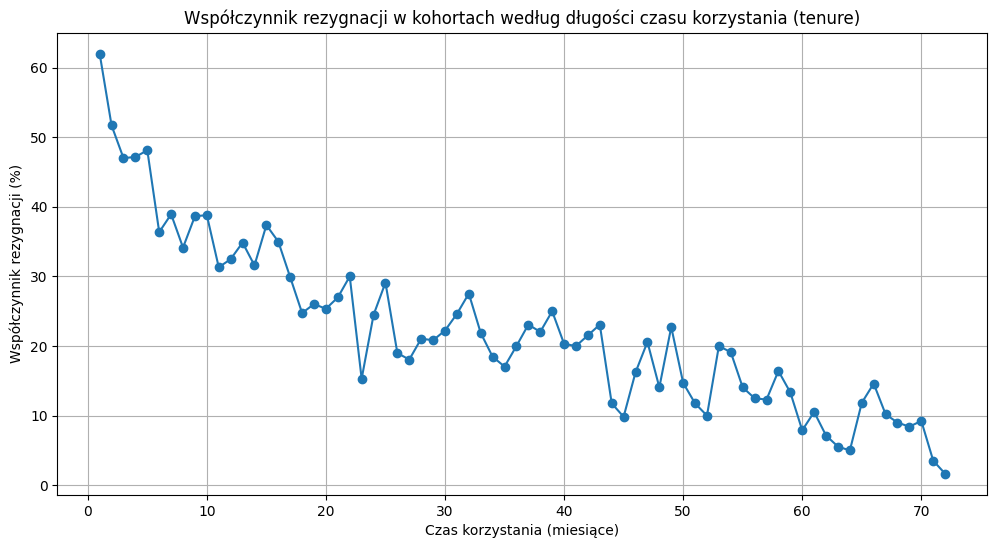

In [16]:
churn_rate_by_tenure = (
    data.groupby('tenure')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='Churn Rate (%)')
)

churn_rate_by_tenure.head(10)

plt.figure(figsize=(12, 6))
plt.plot(churn_rate_by_tenure['tenure'], churn_rate_by_tenure['Churn Rate (%)'], marker='o')
plt.title("Współczynnik rezygnacji w kohortach według długości czasu korzystania (tenure)")
plt.xlabel("Czas korzystania (miesiące)")
plt.ylabel("Współczynnik rezygnacji (%)")
plt.grid()
plt.show()

1.11. Wykres zależności współczynnika rezygnacji od 'tenure' w miesiącach.

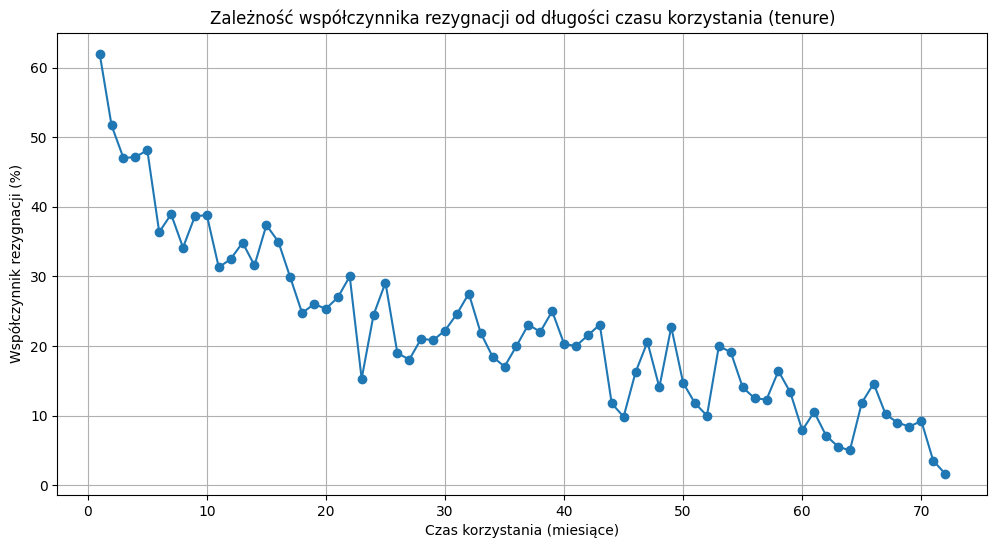

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(churn_rate_by_tenure['tenure'], churn_rate_by_tenure['Churn Rate (%)'], marker='o', linestyle='-')
plt.title("Zależność współczynnika rezygnacji od długości czasu korzystania (tenure)")
plt.xlabel("Czas korzystania (miesiące)")
plt.ylabel("Współczynnik rezygnacji (%)")
plt.grid()
plt.show()

1.12. Na podstawie wartości kolumny 'tenure' należy stworzyć nową kolumnę, dzieląc 'tenure' na 4
grupy: '0-12 miesięcy, '12-24 miesięcy, '24-48 miesięcy, ‘Powyżej 48 miesięcy’.

In [18]:
def categorize_tenure(tenure):
    if tenure <= 12:
        return '0-12 miesięcy'
    elif tenure <= 24:
        return '12-24 miesięcy'
    elif tenure <= 48:
        return '24-48 miesięcy'
    else:
        return 'Powyżej 48 miesięcy'

data['Tenure Group'] = data['tenure'].apply(categorize_tenure)

data[['tenure', 'Tenure Group']].head(10)

,tenure,Tenure Group
0,1,0-12 miesięcy
1,34,24-48 miesięcy
2,2,0-12 miesięcy
3,45,24-48 miesięcy
4,2,0-12 miesięcy
5,8,0-12 miesięcy
6,22,12-24 miesięcy
7,10,0-12 miesięcy
8,28,24-48 miesięcy
9,62,Powyżej 48 miesięcy


1.13. Wykres pudełkowy długości czasu korzystania z usług ('tenure') podzielony na 4 grupy w
zależności od 'Churn'.

<Figure size 1000x600 with 0 Axes>

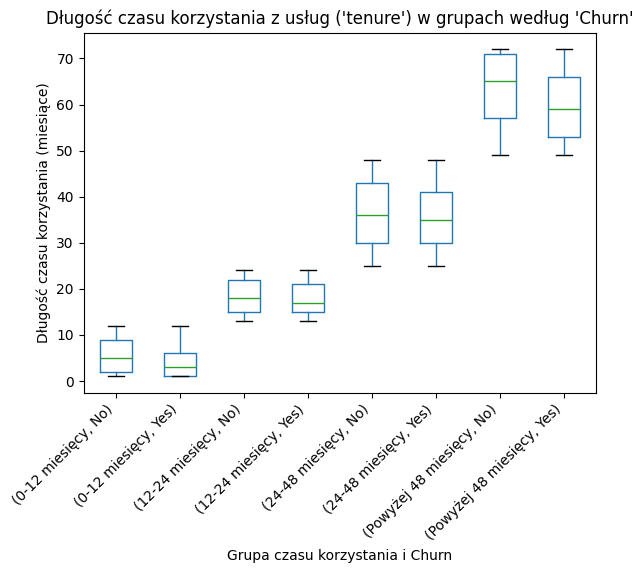

In [19]:
plt.figure(figsize=(10, 6))
data.boxplot(column='tenure', by=['Tenure Group', 'Churn'], grid=False)
plt.title("Długość czasu korzystania z usług ('tenure') w grupach według 'Churn'")
plt.suptitle("")
plt.xlabel("Grupa czasu korzystania i Churn")
plt.ylabel("Długość czasu korzystania (miesiące)")
plt.xticks(rotation=45, ha='right')
plt.show()

Podział zbioru

2.1. Podział danych na macierz cech oraz etykiety. Należy stworzyć obiekt DataFrame z odpowiednimi
zmiennymi fikcyjnymi. Należy pamiętać, że niektóre kolumny można pominąć.

In [20]:
columns_to_drop = ['customerID', 'Churn', 'Tenure Group']
features = data.drop(columns=columns_to_drop)

features = pd.get_dummies(features, drop_first=True)

labels = data['Churn'].map({'Yes': 1, 'No': 0})

features.shape, labels.shape, features.head(), labels.head()

((7032, 30),
 (7032,),
    SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
 0              0       1           29.85         29.85        False   
 1              0      34           56.95       1889.50         True   
 2              0       2           53.85        108.15         True   
 3              0      45           42.30       1840.75         True   
 4              0       2           70.70        151.65        False   
 
    Partner_Yes  Dependents_Yes  PhoneService_Yes  \
 0         True           False             False   
 1        False           False              True   
 2        False           False              True   
 3        False           False             False   
 4        False           False              True   
 
    MultipleLines_No phone service  MultipleLines_Yes  ...  \
 0                            True              False  ...   
 1                           False              False  ...   
 2                           False   

2.2. Podział zbioru danych na treningowy i testowy, z ustawionym random_state=42, tak aby zbiór
testowy zawierał co najmniej 1100 przykładów.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=1100 / len(features), random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5932, 30), (1100, 30), (5932,), (1100,))

Wybór, optymalizacja modeli oraz ewaluacja

3. Model drzewa decyzyjnego

3.1. Zastosowanie klasyfikatora drzewa decyzyjnego przy ustawieniach domyślnych.

In [22]:
decision_tree_default = DecisionTreeClassifier(random_state=42)

decision_tree_default.fit(X_train, y_train)

y_pred_default = decision_tree_default.predict(X_test)

accuracy_default = accuracy_score(y_test, y_pred_default)
report_default = classification_report(y_test, y_pred_default)

print(f"Accuracy (default settings): {accuracy_default}")
print("Classification Report (default settings):")
print(report_default)

Accuracy (default settings): 0.7018181818181818
Classification Report (default settings):
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       804
           1       0.45      0.46      0.45       296

    accuracy                           0.70      1100
   macro avg       0.62      0.63      0.62      1100
weighted avg       0.70      0.70      0.70      1100



3.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów i drzewo decyzyjne na podstawie
predykcji na zbiorze testowym.


Macierz błędów (ustawienia domyślne):
[[636 168]
 [160 136]]


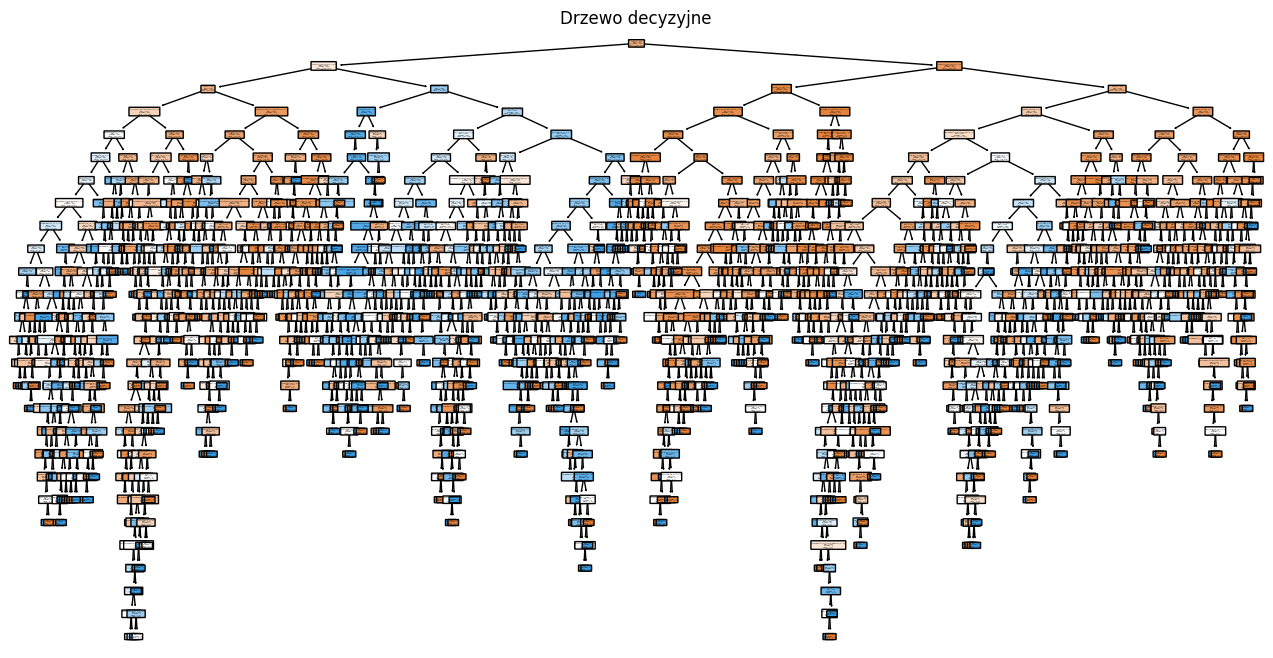

In [23]:
confusion_matrix_default = confusion_matrix(y_test, y_pred_default)
print("\nMacierz błędów (ustawienia domyślne):")
print(confusion_matrix_default)

plt.figure(figsize=(16, 8))
plot_tree(
    decision_tree_default, feature_names=features.columns, class_names=['No', 'Yes'], filled=True, rounded=True
)
plt.title("Drzewo decyzyjne")
plt.show()


3.3. Informacja nt. wagi cech.

Wagi cech (Feature Importances):
                                  Feature  Importance
1                                  tenure    0.216979
2                          MonthlyCharges    0.192919
3                            TotalCharges    0.189414
10            InternetService_Fiber optic    0.110628
4                             gender_Male    0.026295
6                          Dependents_Yes    0.023105
28         PaymentMethod_Electronic check    0.022238
5                             Partner_Yes    0.020130
0                           SeniorCitizen    0.019096
9                       MultipleLines_Yes    0.018396
26                   PaperlessBilling_Yes    0.018320
24                      Contract_One year    0.017278
19                        TechSupport_Yes    0.016160
15                       OnlineBackup_Yes    0.014773
27  PaymentMethod_Credit card (automatic)    0.014481
13                     OnlineSecurity_Yes    0.014089
17                   DeviceProtection_Yes    0.01

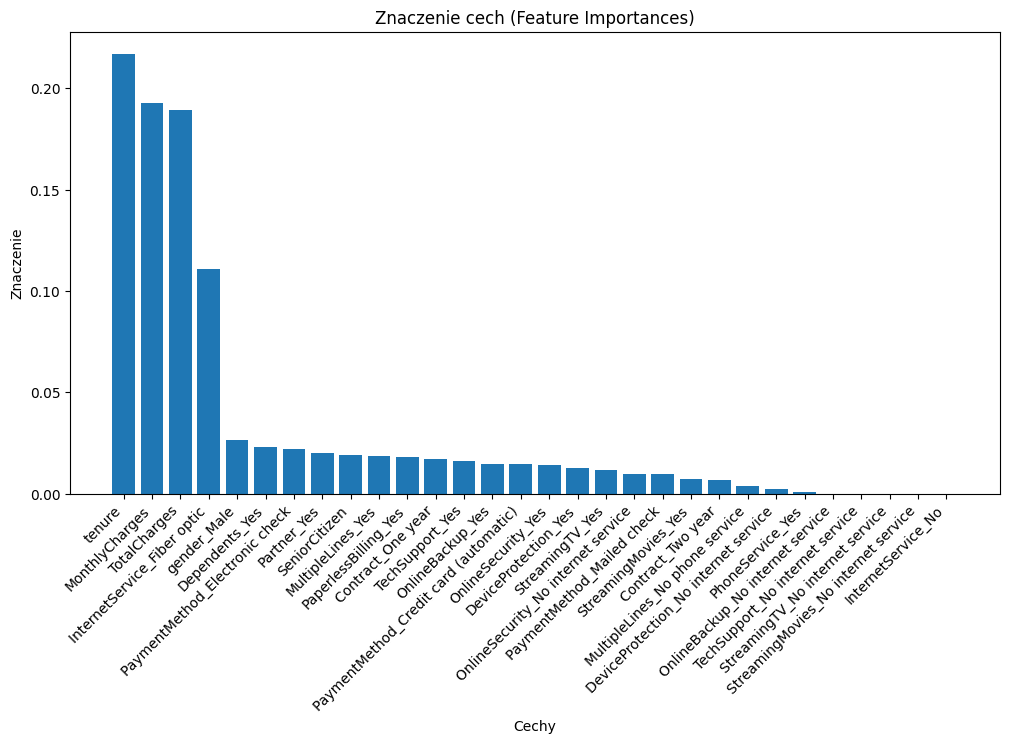

In [24]:
feature_importances = decision_tree_default.feature_importances_

importances_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Wagi cech (Feature Importances):")
print(importances_df)

plt.figure(figsize=(12, 6))
plt.bar(importances_df['Feature'], importances_df['Importance'])
plt.title("Znaczenie cech (Feature Importances)")
plt.xlabel("Cechy")
plt.ylabel("Znaczenie")
plt.xticks(rotation=45, ha='right')
plt.show()

4. Model k-najbliższych sąsiadów

4.1. Zastosowanie klasyfikatora k-najbliższych sąsiadów przy ustawieniach domyślnych.

In [25]:
knn_default = KNeighborsClassifier()

knn_default.fit(X_train, y_train)

y_pred_knn_default = knn_default.predict(X_test)

accuracy_knn_default = accuracy_score(y_test, y_pred_knn_default)
report_knn_default = classification_report(y_test, y_pred_knn_default)
conf_matrix_knn_default = confusion_matrix(y_test, y_pred_knn_default)

4.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [26]:
print("Classification Report (KNN):")
print(classification_report(y_test, y_pred_knn_default))

print("\nMacierz błędów (KNN):")
print(confusion_matrix(y_test, y_pred_knn_default))

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       804
           1       0.57      0.45      0.50       296

    accuracy                           0.76      1100
   macro avg       0.69      0.66      0.67      1100
weighted avg       0.75      0.76      0.75      1100


Macierz błędów (KNN):
[[706  98]
 [164 132]]


5. Model regresji logistycznej

5.1. Zastosowanie klasyfikatora regresji logistycznej przy ustawieniach domyślnych.

In [27]:
logistic_regression = LogisticRegression(random_state=42, max_iter=1000)

logistic_regression.fit(X_train, y_train)

y_pred_logistic = logistic_regression.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
report_logistic = classification_report(y_test, y_pred_logistic)
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


5.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [28]:
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logistic))

print("\nMacierz błędów (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_logistic))

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       804
           1       0.63      0.51      0.56       296

    accuracy                           0.79      1100
   macro avg       0.73      0.70      0.71      1100
weighted avg       0.78      0.79      0.78      1100


Macierz błędów (Logistic Regression):
[[714  90]
 [145 151]]


6.2. Zastosować metodę przeszukiwania siatki lub przeszukiwania losowego w celu doboru
optymalnych parametrów i zbudowanie odpowiednio modelu drzewa decyzyjnego, k-najbliższych
sąsiadów i regresji logistycznej. Należy wyświetlić raporty z klasyfikacji oraz macierze błędów na
podstawie predykcji na zbiorze testowym dla każdego z zoptymalizowanych klasyfikatorów.

In [29]:
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid_search.fit(X_train, y_train)
best_dt = dt_grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid_search.fit(X_train, y_train)
best_knn = knn_grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

lr_params = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}
lr_grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), lr_params, cv=5, scoring='accuracy')
lr_grid_search.fit(X_train, y_train)
best_lr = lr_grid_search.best_estimator_
y_pred_lr = best_lr.predict(X_test)

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [ ]:
print("=== Drzewo Decyzyjne ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

=== Drzewo Decyzyjne ===
Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       804
           1       0.66      0.38      0.48       296

    accuracy                           0.78      1100
   macro avg       0.73      0.65      0.67      1100
weighted avg       0.76      0.78      0.76      1100

Confusion Matrix:
[[747  57]
 [184 112]]


Wagi cech (Feature Importances):
                                  Feature  Importance
1                                  tenure    0.540845
10            InternetService_Fiber optic    0.419740
3                            TotalCharges    0.027651
25                      Contract_Two year    0.011764
0                           SeniorCitizen    0.000000
17                   DeviceProtection_Yes    0.000000
28         PaymentMethod_Electronic check    0.000000
27  PaymentMethod_Credit card (automatic)    0.000000
26                   PaperlessBilling_Yes    0.000000
24                      Contract_One year    0.000000
23                    StreamingMovies_Yes    0.000000
22    StreamingMovies_No internet service    0.000000
21                        StreamingTV_Yes    0.000000
20        StreamingTV_No internet service    0.000000
19                        TechSupport_Yes    0.000000
18        TechSupport_No internet service    0.000000
15                       OnlineBackup_Yes    0.00

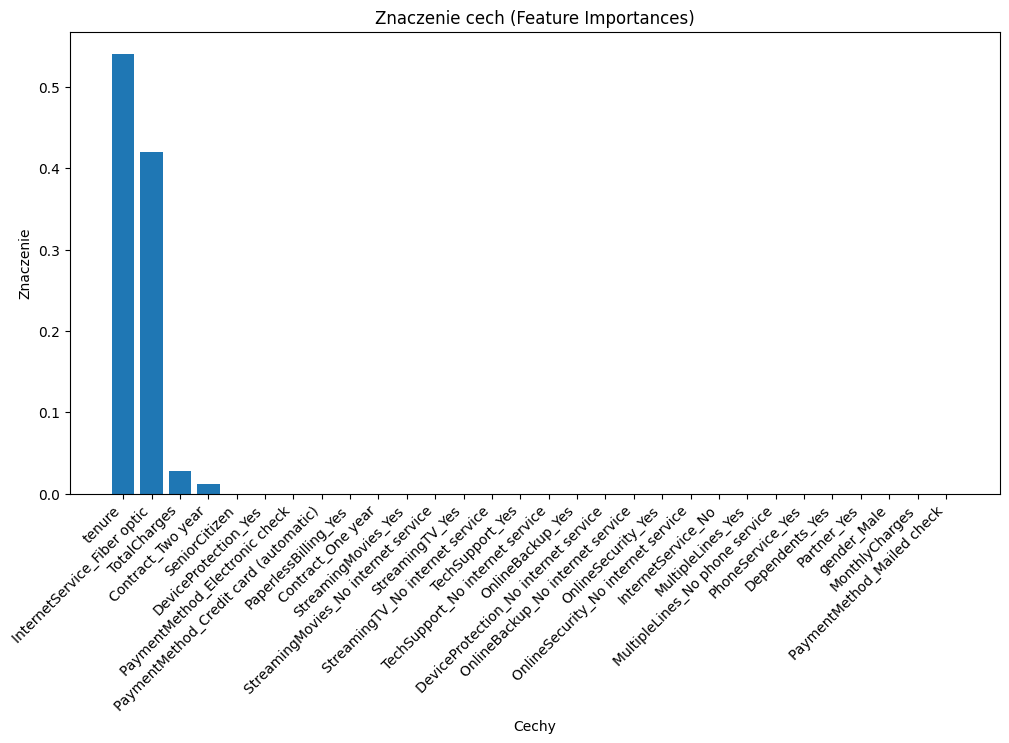

In [32]:
best_dt = dt_grid_search.best_estimator_

feature_importances = best_dt.feature_importances_

importances_df = pd.DataFrame({
    'Feature': X_train.columns,  
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Wagi cech (Feature Importances):")
print(importances_df)

plt.figure(figsize=(12, 6))
plt.bar(importances_df['Feature'], importances_df['Importance'])
plt.title("Znaczenie cech (Feature Importances)")
plt.xlabel("Cechy")
plt.ylabel("Znaczenie")
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
print("\n=== K-Najbliższych Sąsiadów ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


=== K-Najbliższych Sąsiadów ===
Best Parameters: {'n_neighbors': 9, 'weights': 'uniform'}
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       804
           1       0.62      0.43      0.50       296

    accuracy                           0.77      1100
   macro avg       0.71      0.66      0.68      1100
weighted avg       0.76      0.77      0.76      1100

Confusion Matrix:
[[726  78]
 [170 126]]


In [ ]:
print("\n=== Regresja Logistyczna ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


=== Regresja Logistyczna ===
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       804
           1       0.63      0.50      0.56       296

    accuracy                           0.79      1100
   macro avg       0.73      0.70      0.71      1100
weighted avg       0.78      0.79      0.78      1100

Confusion Matrix:
[[716  88]
 [147 149]]
